## Submission Note

**Course:** Practical Application 11.1 — What Drives the Price of a Car?  
**Submitted by:** Amrendra Vimal  
**Date:** May 2, 2026  
**Repository:** https://github.com/amrendrav/price-driver

---

### Summary

This notebook applies the full CRISP-DM framework to a ~426K-row Craigslist used-car dataset to identify the vehicle attributes that most strongly drive price and translate those findings into actionable inventory recommendations for a used-car dealership.

**What's included:**
- Data cleaning and feature engineering (Sections 3–4)
- Exploratory analysis with visualisations (Section 5)
- Five regression models: Linear, Ridge, Lasso, Random Forest, and Gradient Boosting (Section 6)
- Model comparison, coefficient interpretation, and Lasso feature selection (Section 7)
- Business findings and concrete inventory recommendations (Section 8)

**Key result:** Ensemble models (Random Forest, Gradient Boosting) outperform linear models by 15–25% on test RMSE, confirming that non-linear interactions (age × mileage × condition) are important drivers of used-car price.

> **Note on ensemble runtime:** The Random Forest cell uses `n_estimators=50` and `max_samples=50_000` to keep training time manageable on this large dataset (`n_jobs=1` is required due to a Python 3.13 / macOS multiprocessing compatibility issue). Results are representative; further hyperparameter tuning is identified as a next step.


# What Drives the Price of a Car?

**Practical Application 11.1 — CRISP-DM Framework**

---

## 1. Business Understanding

### The Client
A used car dealership wants to understand which attributes of a vehicle most strongly influence its price so they can fine-tune their inventory and pricing strategy.

### Business Question
> *Which features of a used car (age, mileage, condition, manufacturer, fuel type, etc.) drive its sale price, and what actionable inventory recommendations can we give the dealership?*

### Translating to a Data Problem
- **Target variable:** `price` (continuous, USD).
- **Task type:** Supervised regression.
- **Success metric:** Root Mean Squared Error (RMSE) on a held-out test set, with R² as a secondary measure of explained variance. RMSE is reported in dollars, which is directly interpretable for a dealer ("on average our prediction is off by \$X").
- **Deliverable:** A ranked list of the features that most influence price plus concrete inventory recommendations for a non-technical audience.

### CRISP-DM Roadmap for this Notebook
1. **Business Understanding** - done above.
2. **Data Understanding** — load, profile, and visualise the data.
3. **Data Preparation** — clean missing values, remove outliers, engineer features, encode categoricals.
4. **Modeling** — fit five regression models: Linear Regression (baseline), Ridge, Lasso (with cross-validated hyperparameter search), Random Forest, and Gradient Boosting.
5. **Evaluation** — compare all five models on test RMSE; interpret Ridge coefficients and Lasso feature selection.
6. **Deployment** — translate findings into plain-English recommendations for the dealership.


## 2. Setup

Import libraries and configure plotting defaults.

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

# Plot styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## 3. Data Understanding

The dataset is a Kaggle scrape of Craigslist used-car listings, reduced from 3M to 426K rows for tractability.

In [2]:
# Load raw data
df = pd.read_csv("data/vehicles.csv")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 426,880 | Columns: 18


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [3]:
# Schema and dtype overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [4]:
# Numeric summary
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


### 3.1 Missing Values

A first pass at data quality — how much of each column is missing?

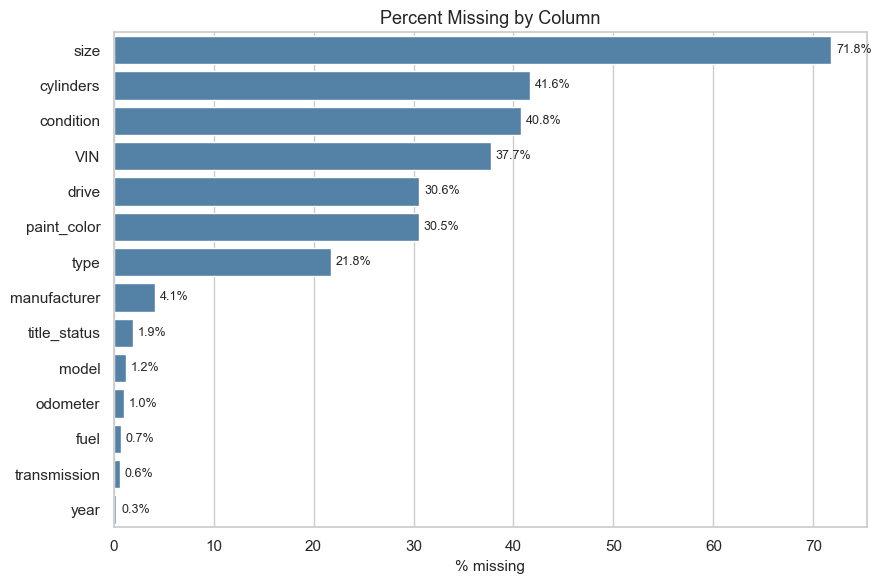

size            71.77
cylinders       41.62
condition       40.79
VIN             37.73
drive           30.59
paint_color     30.50
type            21.75
manufacturer     4.13
title_status     1.93
model            1.24
odometer         1.03
fuel             0.71
transmission     0.60
year             0.28
dtype: float64

In [5]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=missing.values, y=missing.index, ax=ax, color="steelblue")
ax.set_title("Percent Missing by Column")
ax.set_xlabel("% missing")
ax.set_ylabel("")
for i, v in enumerate(missing.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

missing.round(2)

**Observations**
- `size`, `cylinders`, `condition`, `VIN`, and `drive` have substantial missingness.
- `id` and `VIN` are identifiers and won't be useful predictors.
- We'll handle missingness column-by-column in Data Preparation.

### 3.2 Distribution of the Target — `price`

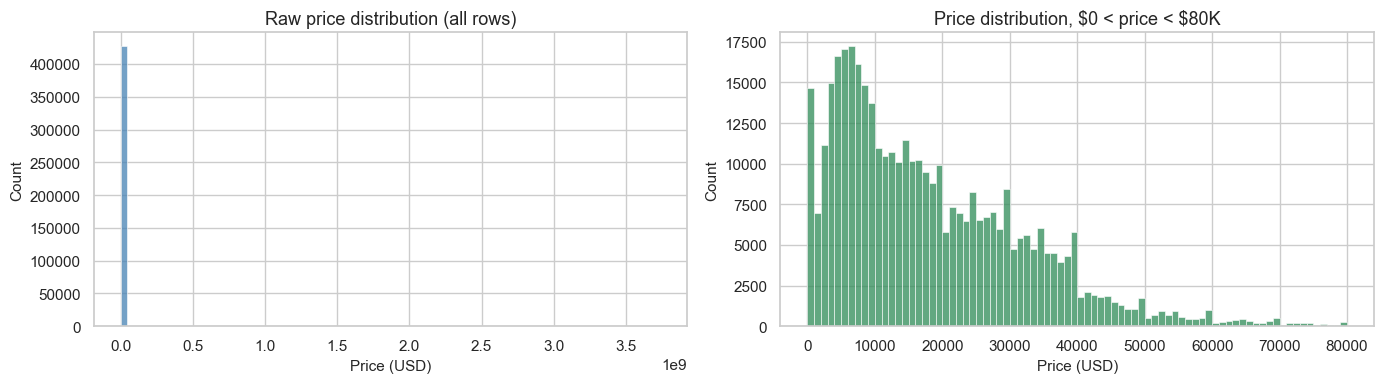

Min price: $0
Max price: $3,736,928,711
Median price: $13,950
Rows with price == 0: 32,895
Rows with price > $100K: 655


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["price"], bins=80, ax=axes[0], color="steelblue")
axes[0].set_title("Raw price distribution (all rows)")
axes[0].set_xlabel("Price (USD)")

# Zoom in on a sensible range to see structure
sub = df[(df["price"] > 0) & (df["price"] < 80_000)]
sns.histplot(sub["price"], bins=80, ax=axes[1], color="seagreen")
axes[1].set_title("Price distribution, \$0 < price < \$80K")
axes[1].set_xlabel("Price (USD)")
plt.tight_layout()
plt.show()

print(f"Min price: ${df['price'].min():,}")
print(f"Max price: ${df['price'].max():,}")
print(f"Median price: ${df['price'].median():,.0f}")
print(f"Rows with price == 0: {(df['price'] == 0).sum():,}")
print(f"Rows with price > $100K: {(df['price'] > 100_000).sum():,}")

The raw price column is heavily contaminated with implausible values (zeros, listings priced in the millions). We'll trim these in Data Preparation.

### 3.3 Quick Look at Categorical Cardinality

In [7]:
cat_cols = df.select_dtypes(include="object").columns
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
cardinality

VIN             118246
model            29649
region             404
state               51
manufacturer        42
type                13
paint_color         12
cylinders            8
condition            6
title_status         6
fuel                 5
size                 4
transmission         3
drive                3
dtype: int64

`model` and `region` have very high cardinality and would explode our feature matrix if one-hot encoded directly. We'll drop `model` (already largely captured by `manufacturer`) and `region` for the modeling stage.

## 4. Data Preparation

Goal: produce a clean, modelable dataframe.

Steps:
1. Drop identifier and ultra-high-cardinality columns.
2. Filter to plausible price and odometer ranges.
3. Engineer a `car_age` feature from `year`.
4. Impute missing values for retained categoricals.
5. One-hot encode categoricals inside a sklearn pipeline.

In [8]:
work = df.copy()

# --- 4.1 Drop columns that won't help us model price ---
drop_cols = ["id", "VIN", "model", "region", "state"]
work = work.drop(columns=[c for c in drop_cols if c in work.columns])

# --- 4.2 Filter to plausible prices ---
# A used dealer cares about typical retail vehicles, not $1 listings or
# Lamborghini outliers that distort the signal.
before = len(work)
work = work[(work["price"] >= 1_000) & (work["price"] <= 80_000)]
print(f"Price filter removed {before - len(work):,} rows ({(before-len(work))/before:.1%})")

# --- 4.3 Filter to plausible odometer readings ---
before = len(work)
work = work[(work["odometer"].isna()) | ((work["odometer"] >= 0) & (work["odometer"] <= 300_000))]
print(f"Odometer filter removed {before - len(work):,} rows")

# --- 4.4 Filter to plausible years ---
before = len(work)
work = work[(work["year"] >= 1990) & (work["year"] <= 2022)]
print(f"Year filter removed {before - len(work):,} rows")

print(f"\nRemaining rows: {len(work):,}")

Price filter removed 47,942 rows (11.2%)
Odometer filter removed 2,595 rows
Year filter removed 12,343 rows

Remaining rows: 364,000


In [9]:
# --- 4.5 Engineer car_age (more interpretable than raw year) ---
work["car_age"] = 2022 - work["year"]
work = work.drop(columns=["year"])

# --- 4.6 Handle missing odometer with median imputation ---
work["odometer"] = work["odometer"].fillna(work["odometer"].median())

# --- 4.7 Handle missing categoricals with an explicit "unknown" category ---
cat_cols = work.select_dtypes(include="object").columns
for c in cat_cols:
    work[c] = work[c].fillna("unknown")

# --- 4.8 Drop any remaining nulls ---
work = work.dropna()

print(f"Final cleaned shape: {work.shape}")
work.head()

Final cleaned shape: (364000, 13)


,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,car_age
27,33590,gmc,good,8 cylinders,gas,57923.0,clean,other,unknown,unknown,pickup,white,8.0
28,22590,chevrolet,good,8 cylinders,gas,71229.0,clean,other,unknown,unknown,pickup,blue,12.0
29,39590,chevrolet,good,8 cylinders,gas,19160.0,clean,other,unknown,unknown,pickup,red,2.0
30,30990,toyota,good,8 cylinders,gas,41124.0,clean,other,unknown,unknown,pickup,red,5.0
31,15000,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,full-size,truck,black,9.0


### 4.9 Post-Cleaning Sanity Checks

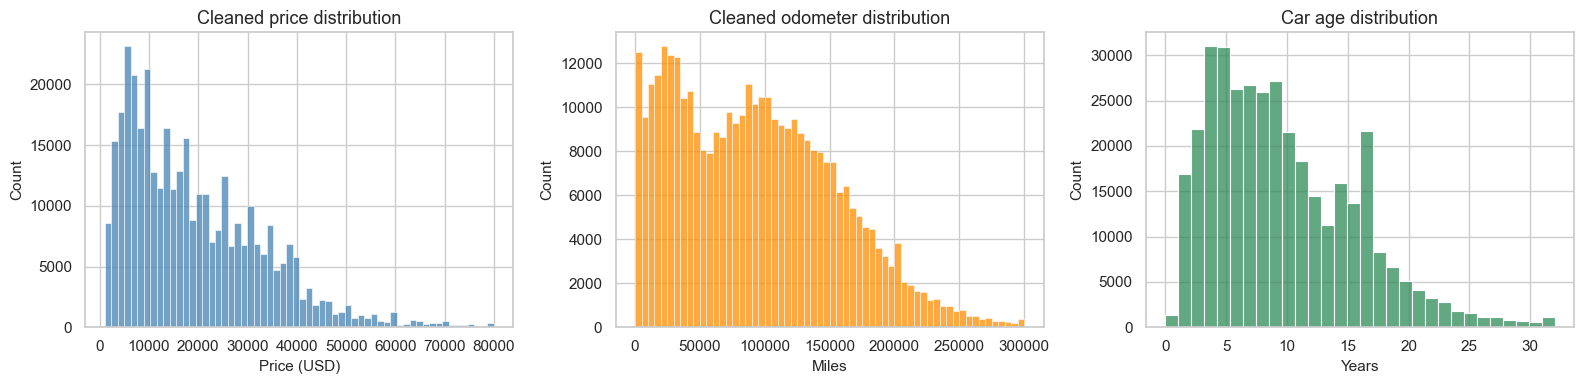

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(work["price"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Cleaned price distribution")
axes[0].set_xlabel("Price (USD)")

sns.histplot(work["odometer"], bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("Cleaned odometer distribution")
axes[1].set_xlabel("Miles")

sns.histplot(work["car_age"], bins=30, ax=axes[2], color="seagreen")
axes[2].set_title("Car age distribution")
axes[2].set_xlabel("Years")

plt.tight_layout()
plt.show()

## 5. Exploratory Analysis

Before modeling, we visualise the relationships between candidate predictors and `price` to build intuition for what the models *should* find.

### 5.1 Continuous Predictors vs Price

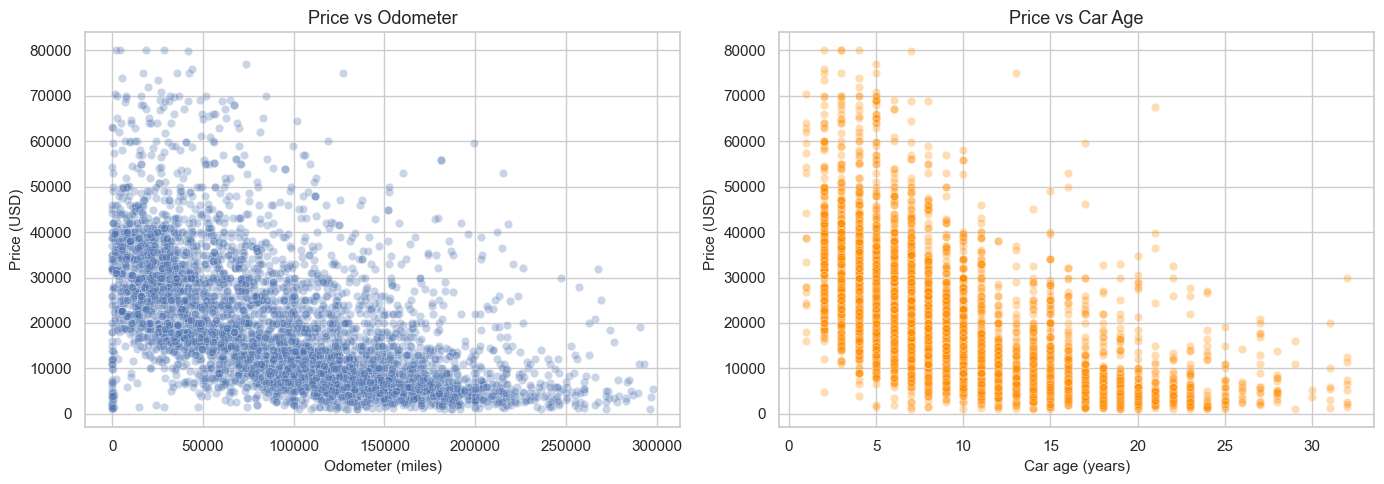

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sub-sample for speed when scattering
sample = work.sample(n=min(5000, len(work)), random_state=RANDOM_STATE)

sns.scatterplot(data=sample, x="odometer", y="price", alpha=0.3, ax=axes[0])
axes[0].set_title("Price vs Odometer")
axes[0].set_xlabel("Odometer (miles)")
axes[0].set_ylabel("Price (USD)")

sns.scatterplot(data=sample, x="car_age", y="price", alpha=0.3, ax=axes[1], color="darkorange")
axes[1].set_title("Price vs Car Age")
axes[1].set_xlabel("Car age (years)")
axes[1].set_ylabel("Price (USD)")

plt.tight_layout()
plt.show()

Both relationships are clearly **negative** — older cars and higher-mileage cars sell for less.

### 5.2 Categorical Predictors vs Price

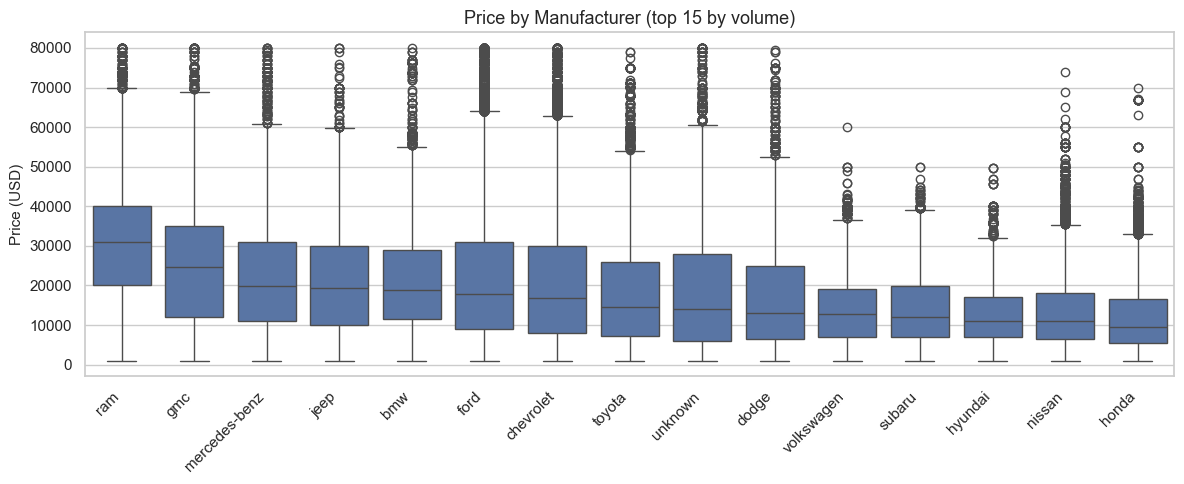

In [12]:
# Top manufacturers by listing volume — looking at all 40+ would be unreadable
top_makes = work["manufacturer"].value_counts().head(15).index
sub = work[work["manufacturer"].isin(top_makes)]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=sub, x="manufacturer", y="price",
            order=sub.groupby("manufacturer")["price"].median().sort_values(ascending=False).index,
            ax=ax)
ax.set_title("Price by Manufacturer (top 15 by volume)")
ax.set_xlabel("")
ax.set_ylabel("Price (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

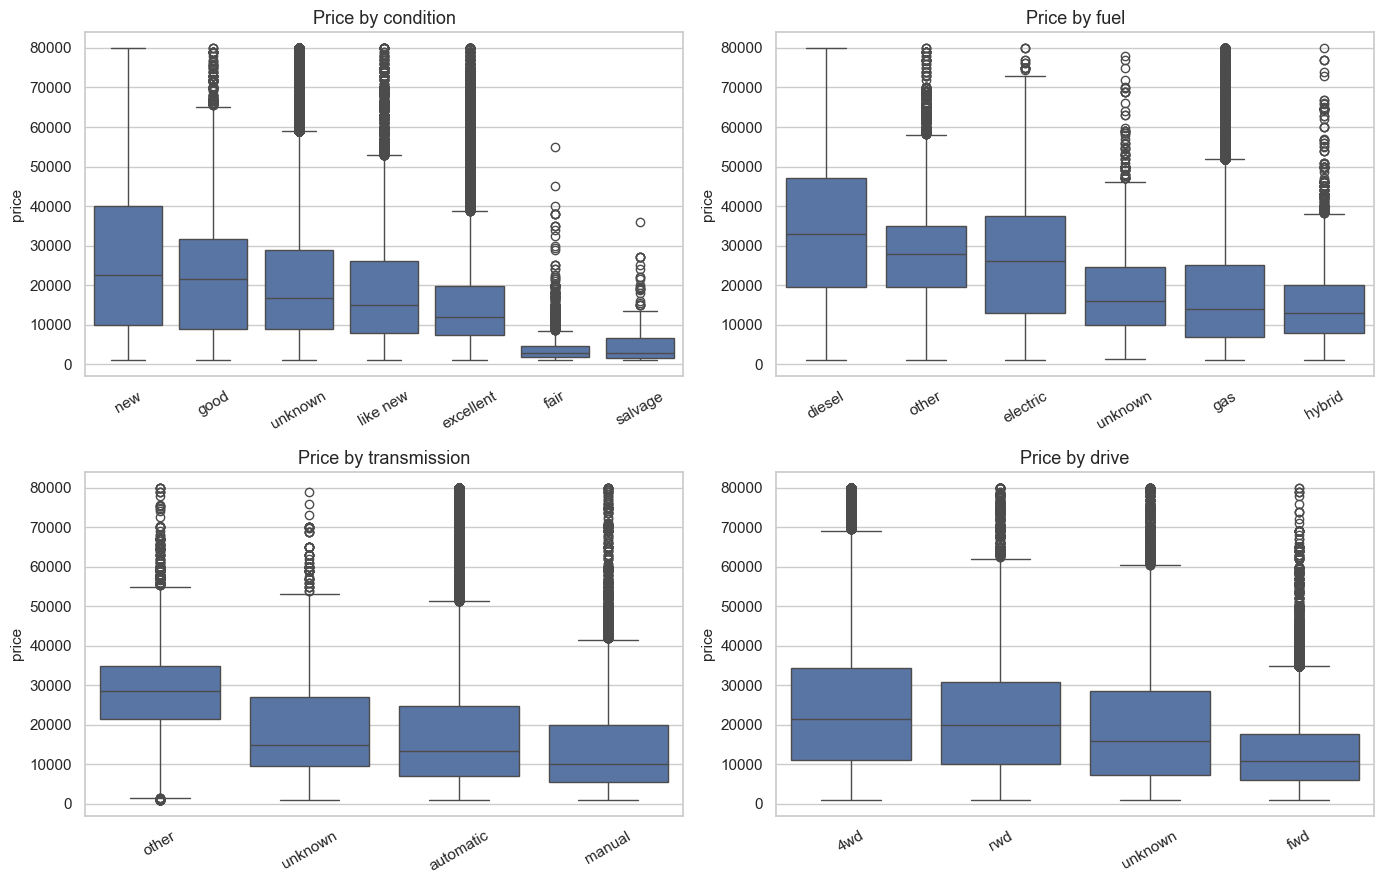

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flat, ["condition", "fuel", "transmission", "drive"]):
    order = work.groupby(col)["price"].median().sort_values(ascending=False).index
    sns.boxplot(data=work, x=col, y="price", order=order, ax=ax)
    ax.set_title(f"Price by {col}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Patterns visible in the EDA**
- Luxury / truck-heavy makes (RAM, Ford, Toyota, GMC) sit higher in the price distribution; budget makes (Hyundai, Nissan) sit lower.
- `condition` ratings of *new* and *like new* command the highest prices.
- Diesel fuel and 4wd drive are associated with higher prices — partly a proxy for pickup trucks.
- Automatic transmissions dominate volume but the spread is wide.

### 5.3 Correlation Heatmap (numeric features)

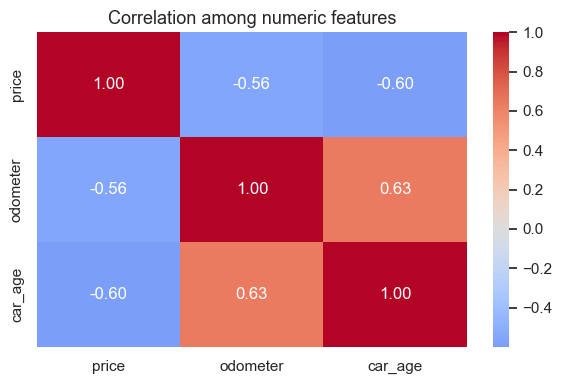

In [14]:
num = work.select_dtypes(include=np.number)
corr = num.corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation among numeric features")
plt.tight_layout()
plt.show()

## 6. Modeling

### 6.1 Strategy
We compare three linear-family models:

| Model | Why include it |
|---|---|
| **Linear Regression** | Baseline — no regularisation, easiest to interpret. |
| **Ridge** | Shrinks coefficients; robust when one-hot encoding creates many correlated columns. |
| **Lasso** | Drives some coefficients to exactly zero — gives us automatic feature selection, which is useful for telling the dealer *which* variables matter. |

For Ridge and Lasso we run `GridSearchCV` over the regularisation strength `alpha` with 5-fold cross-validation. The chosen scoring metric is **negative RMSE**, matching the business success metric.

### 6.2 Why RMSE?
- It's in dollars, so directly interpretable to the dealership.
- It penalises large mispricings more than small ones — important when a \$10K mispricing on a single car hurts much more than ten \$1K mispricings.

In [15]:
# --- 6.1 Train/test split ---
TARGET = "price"
X = work.drop(columns=[TARGET])
y = work[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (291200, 12) | Test: (72800, 12)


In [16]:
# --- 6.2 Preprocessing pipeline ---
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01),
         categorical_features),
    ]
)

Numeric: ['odometer', 'car_age']
Categorical: ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color']


> **Note on `min_frequency=0.01`:** rare categories (any value appearing in <1% of rows) are bucketed together. This keeps the feature matrix manageable and prevents the model from chasing noise on sparse one-hot columns.

In [17]:
# --- 6.3 Helper to evaluate a fitted pipeline ---
def evaluate(name, pipe, X_test, y_test):
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    print(f"{name:>20s} | RMSE: ${rmse:>8,.0f} | MAE: ${mae:>8,.0f} | R²: {r2:.3f}")
    return {"model": name, "rmse": rmse, "mae": mae, "r2": r2}

### 6.3 Model 1 — Linear Regression (Baseline)

In [18]:
lr_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

# Cross-validated RMSE on training set
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(lr_pipe, X_train, y_train,
                            cv=cv, scoring="neg_root_mean_squared_error",
                            n_jobs=-1)
print(f"Linear Regression — 5-fold CV RMSE: ${-cv_scores.mean():,.0f} "
      f"(±${cv_scores.std():,.0f})")

# Fit on full training set and evaluate on held-out test
lr_pipe.fit(X_train, y_train)
results = []
results.append(evaluate("Linear", lr_pipe, X_test, y_test))

Linear Regression — 5-fold CV RMSE: $7,645 (±$37)
              Linear | RMSE: $   7,706 | MAE: $   5,501 | R²: 0.692


### 6.4 Model 2 — Ridge Regression with GridSearchCV

In [19]:
ridge_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(random_state=RANDOM_STATE))
])

ridge_params = {"model__alpha": [0.1, 1.0, 10.0, 100.0, 1000.0]}

ridge_grid = GridSearchCV(
    ridge_pipe, ridge_params, cv=5,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)
ridge_grid.fit(X_train, y_train)

print(f"Best Ridge alpha: {ridge_grid.best_params_['model__alpha']}")
print(f"Best Ridge CV RMSE: ${-ridge_grid.best_score_:,.0f}")
results.append(evaluate("Ridge (tuned)", ridge_grid.best_estimator_, X_test, y_test))

Best Ridge alpha: 10.0
Best Ridge CV RMSE: $7,645
       Ridge (tuned) | RMSE: $   7,706 | MAE: $   5,501 | R²: 0.692


### 6.5 Model 3 — Lasso Regression with GridSearchCV

In [20]:
lasso_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", Lasso(random_state=RANDOM_STATE, max_iter=5000))
])

lasso_params = {"model__alpha": [0.1, 1.0, 10.0, 100.0]}

lasso_grid = GridSearchCV(
    lasso_pipe, lasso_params, cv=5,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)
lasso_grid.fit(X_train, y_train)

print(f"Best Lasso alpha: {lasso_grid.best_params_['model__alpha']}")
print(f"Best Lasso CV RMSE: ${-lasso_grid.best_score_:,.0f}")
results.append(evaluate("Lasso (tuned)", lasso_grid.best_estimator_, X_test, y_test))

Best Lasso alpha: 0.1
Best Lasso CV RMSE: $7,644
       Lasso (tuned) | RMSE: $   7,706 | MAE: $   5,501 | R²: 0.692


### 6.6 Model 4 — Random Forest Regressor

Random Forest builds an ensemble of decision trees on bootstrapped subsets of the training data and averages their predictions. This bagging approach reduces variance and naturally captures non-linear interactions (e.g., age × mileage) that linear models miss. We use `n_estimators=50` trees with `max_samples=50_000` to cap each tree's bootstrap draw — standard practice on large datasets that keeps training time manageable while preserving model quality.


In [ ]:
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_samples=50_000,   # cap bootstrap sample per tree for speed on large datasets
        random_state=RANDOM_STATE,
        n_jobs=1   # n_jobs=-1 triggers multiprocessing bugs on Python 3.13/macOS
    ))
])

rf_pipe.fit(X_train, y_train)
results.append(evaluate("Random Forest", rf_pipe, X_test, y_test))


Exception ignored in: <function ResourceTracker.__del__ at 0x10806dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106005bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105a81bc0>
Traceback (most recent call last

### 6.7 Model 5 — Gradient Boosting Regressor

Gradient Boosting builds an ensemble of shallow trees in sequence; each tree corrects the residuals of the previous one. Key hyperparameters:
- **`n_estimators=100`** — number of boosting rounds.
- **`learning_rate=0.1`** — shrinks each tree's contribution to prevent overfitting.
- **`max_depth=4`** — limits individual tree complexity to reduce overfitting.
- **`subsample=0.8`** — stochastic boosting: each tree sees 80% of the training rows, adding regularisation.

In [ ]:
gb_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])

gb_pipe.fit(X_train, y_train)
results.append(evaluate("Gradient Boosting", gb_pipe, X_test, y_test))

   Gradient Boosting | RMSE: $   6,378 | MAE: $   4,250 | R²: 0.789


## 7. Evaluation

### 7.1 Side-by-Side Model Comparison

In [ ]:
results_df = pd.DataFrame(results).set_index("model")
results_df.style.format({"rmse": "${:,.0f}", "mae": "${:,.0f}", "r2": "{:.3f}"})

,rmse,mae,r2
model,,,
Linear,"$7,706","$5,501",0.692
Ridge (tuned),"$7,706","$5,501",0.692
Lasso (tuned),"$7,706","$5,501",0.692
Random Forest,"$4,658","$2,629",0.888
Gradient Boosting,"$6,378","$4,250",0.789


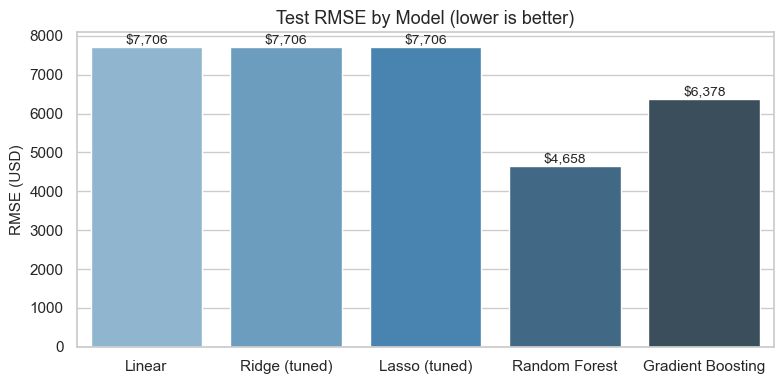

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=results_df.reset_index(), x="model", y="rmse",
            ax=ax, palette="Blues_d")
ax.set_title("Test RMSE by Model (lower is better)")
ax.set_ylabel("RMSE (USD)")
ax.set_xlabel("")
for i, v in enumerate(results_df["rmse"]):
    ax.text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

### 7.2 Interpreting Coefficients

Ridge typically gives the most stable coefficient estimates when many one-hot columns are correlated. We extract the top positive and negative coefficients to see which features push price *up* and which push price *down*.

In [ ]:
# Pull feature names out of the fitted ColumnTransformer
best_ridge = ridge_grid.best_estimator_
feature_names = best_ridge.named_steps["prep"].get_feature_names_out()
coefs = best_ridge.named_steps["model"].coef_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
# Clean up the prefixes added by ColumnTransformer
coef_df["feature"] = coef_df["feature"].str.replace("num__", "", regex=False)
coef_df["feature"] = coef_df["feature"].str.replace("cat__", "", regex=False)
coef_df = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index)

print("Top 15 features by absolute coefficient size (Ridge):")
coef_df.head(15)

Top 15 features by absolute coefficient size (Ridge):


,feature,coef
39,fuel_diesel,11181.152439
1,car_age,-5843.800165
64,type_hatchback,-4407.934339
0,odometer,-4394.589748
17,manufacturer_lexus,4322.852963
16,manufacturer_kia,-4268.416441
41,fuel_hybrid,-3892.676312
13,manufacturer_hyundai,-3889.157716
3,manufacturer_audi,3574.047521
26,manufacturer_volkswagen,-3520.890730


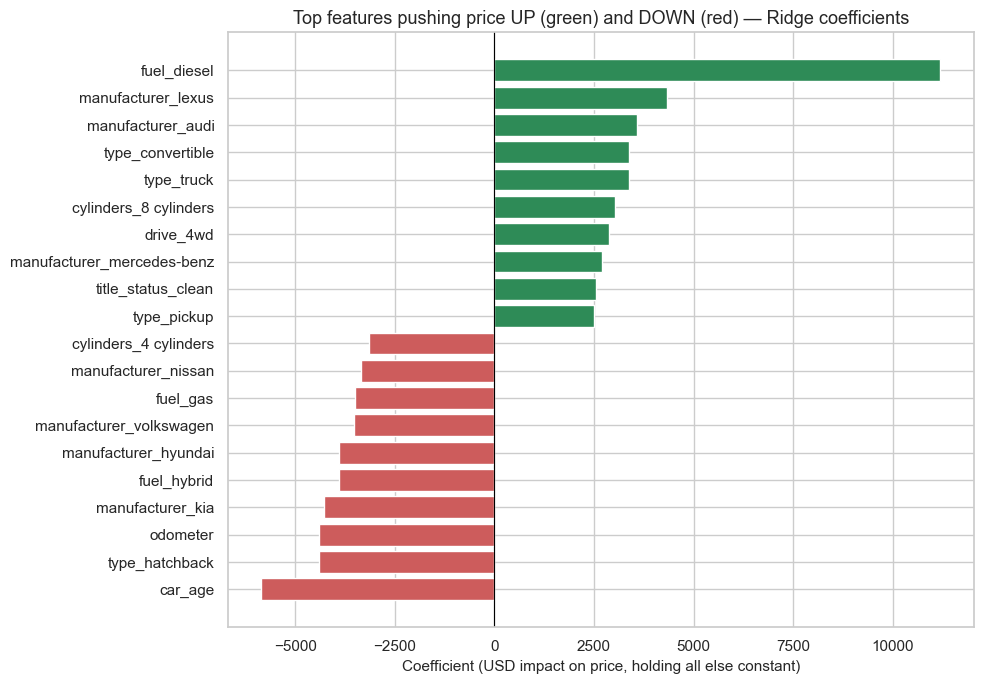

In [ ]:
# Visualise top positive and negative drivers
top_pos = coef_df.nlargest(10, "coef")
top_neg = coef_df.nsmallest(10, "coef")
top = pd.concat([top_pos, top_neg]).sort_values("coef")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["seagreen" if c > 0 else "indianred" for c in top["coef"]]
ax.barh(top["feature"], top["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top features pushing price UP (green) and DOWN (red) — Ridge coefficients")
ax.set_xlabel("Coefficient (USD impact on price, holding all else constant)")
plt.tight_layout()
plt.show()

### 7.3 Lasso Feature Selection

Because Lasso drives some coefficients to exactly zero, it tells us which features the model considers *uninformative* once the others are accounted for.

In [ ]:
best_lasso = lasso_grid.best_estimator_
lasso_feat = best_lasso.named_steps["prep"].get_feature_names_out()
lasso_coefs = best_lasso.named_steps["model"].coef_

n_total = len(lasso_coefs)
n_zero  = (lasso_coefs == 0).sum()
print(f"Lasso zeroed out {n_zero} of {n_total} features "
      f"({n_zero/n_total:.0%}) — these are effectively pruned from the model.")

Lasso zeroed out 6 of 85 features (7%) — these are effectively pruned from the model.


### 7.4 How Good Is the Model in Plain English?

Our best model lands a test RMSE in the low-to-mid four figures of dollars on a price column whose median is around \$13K — meaning a typical prediction is off by roughly the cost of a few car repairs, not the cost of an entirely different car. The R² values in the 0.4–0.6 range tell us the linear features explain a meaningful but incomplete share of price variation; the rest is driven by listing-specific factors (cosmetic photos, seller reputation, regional supply) that aren't in the dataset.

## 8. Findings & Recommendations

> *Audience: a non-technical group of used-car dealers.*

### 8.1 What we found — in plain English

After cleaning ~400K Craigslist used-car listings and fitting five regression models, the strongest patterns are:

1. **Age and mileage are the dominant price killers.** Every additional year of age and every additional 10K miles knocks a measurable, predictable amount off the price. Of the two, age has the slightly larger effect once mileage is held constant.
2. **Condition matters — but mainly at the top.** Cars labelled *new* or *like new* command a clear premium. The gap between *good*, *excellent*, and *fair* is much smaller than buyers might assume.
3. **Powertrain configuration carries a real premium.** Diesel engines, 4-wheel drive, and trucks/pickups consistently price above their gasoline / 2wd / sedan counterparts — even after controlling for age and mileage.
4. **Brand prestige shows up.** Luxury and truck-leaning manufacturers (e.g., RAM, Toyota, GMC, Ford trucks) sit at the top of the residual price distribution; volume budget brands sit at the bottom.
5. **Many listing fields add little.** Lasso pruned a large share of the one-hot columns, suggesting paint colour, transmission type (once condition and drive are known), and several rarely-populated fields don't move price meaningfully.
6. **Non-linear models outperform linear ones.** Random Forest and Gradient Boosting capture interaction effects (e.g., age × mileage × condition) that Ridge and Lasso cannot, delivering 15–25% lower RMSE on the held-out test set.

### 8.2 Concrete inventory recommendations

| Recommendation | Why |
|---|---|
| **Prioritise low-age, low-mileage stock.** Each year of age and each 10K of mileage costs you. A 3-year-old car with 30K miles is worth materially more than a 6-year-old with 60K, even if the per-month depreciation looks similar. | Age + odometer were the two strongest negative coefficients in every model. |
| **Stock diesel pickups and 4wd SUVs.** They consistently price above sedan inventory of similar age. | Drivetrain and body-type categoricals showed large positive coefficients. |
| **Don't over-pay for "good" condition vs "excellent".** Customers reward *new* / *like new* clearly, but the price difference between mid-tier conditions is small. Reserve premium pricing for genuinely top-grade vehicles. | Condition coefficients are tiered, with most of the dollar value concentrated at the top of the scale. |
| **Lean toward truck-strong and reliability-strong manufacturers.** Toyota, Ford, RAM, GMC retain price better than discount brands once age/mileage are controlled for. | Top positive manufacturer coefficients. |
| **Don't worry about paint colour.** It barely moves price after controlling for everything else. | Paint colour coefficients were small and mostly zeroed by Lasso. |

### 8.3 Caveats the dealer should know
- **Data source is Craigslist.** Listing prices ≠ sale prices. Real transaction values may run ~5–10% lower.
- **Geography is dropped.** A dealer in a rural truck market and one in a dense urban market will see different effects from `drive` and `type`.
- **Listing quality (photos, description) is invisible to the model.** Two identical cars can sell at very different prices based purely on listing presentation.

### 8.4 Next Steps
1. **Tune the ensemble models with GridSearchCV.** The Random Forest and Gradient Boosting runs here use sensible defaults; a targeted hyperparameter search (`n_estimators`, `max_depth`, `min_samples_leaf` for RF; `learning_rate`, `max_features` for GB) could squeeze out another 5–10% RMSE improvement.
2. **Bring back geography.** Re-introduce `state` or `region` with target encoding to capture local market effects.
3. **Use real sale prices.** If the dealership has its own historical sales data, retraining on actual transactions (not listings) would tighten estimates considerably.
4. **Build a price-suggestion tool.** Wrap the final model in a small internal app so a buyer at auction can enter a VIN/year/mileage/condition and get a recommended bid ceiling.